# Homework 5

Garrett White

-----------------------------------------------------------
# Parametric Credit Models:
# Nelson-Siegel credit model for smooth hazard rate curves

### This homework  implements some of the concepts introduced in Lecture 6, "Parametric Hazard Rate Models"

### Follow the "Smooth parametric yield and hazard rate curves: the Nelson-Siegel model" in the "Smooth Credit Models" notebook
### You can also take a look at Dr. Mark Hendricks Fixed Income notebooks describing the Nelson-Siegel model calibration on US Treasuries.
-----------------------------------------------------------

In [1]:
!pip install QuantLib-Python

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.2/20.2 MB 36.7 MB/s eta 0:00:00


In [2]:
from google.colab import files
import zipfile
import os

uploaded = files.upload()

zip_path = list(uploaded.keys())[0]

extract_path = "/content/unzipped_files"
os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print(f"\nExtracted to: {extract_path}\n")

for root, dirs, files in os.walk(extract_path):
    level = root.replace(extract_path, "").count(os.sep)
    indent = "  " * level
    print(f"{indent}{os.path.basename(root)}/")

    subindent = "  " * (level + 1)
    for f in files:
        print(f"{subindent}{f}")

Saving UChicago_FINM_35700_CreditMarkets_Spring2025_Homework_5.zip to UChicago_FINM_35700_CreditMarkets_Spring2025_Homework_5.zip

Extracted to: /content/unzipped_files

unzipped_files/
  UChicago_FINM_35700_CreditMarkets_Spring2025_Homework_5/
    credit_market_tools.py
    FINM 35700_CreditMarkets_Spring2026_Examples_QuantLib_Basics.ipynb
    FINM 35700_CreditMarkets_Spring2026_Examples_QuantLib_Advanced.ipynb
    FINM 35700_CreditMarkets_Spring2026_Homework_5.ipynb
    FINM 35700_CreditMarkets_Spring2026_Examples_QuantLib_SmoothCreditModels.ipynb
    data/
      sofr_swaps_symbology_ext.xlsx
      govt_on_the_run.xlsx
      ~$call_schedules.xlsx
      bond_market_prices_eod.xlsx
      bond_symbology.xlsx
      sofr_swaps_market_data_eod_ext.xlsx


In [3]:
import sys

extract_path = "/content/unzipped_files"

for root, dirs, files in os.walk(extract_path):
    if "credit_market_tools.py" in files:
        base_path = root
        break

print("Using path:", base_path)

sys.path.append(base_path)

from credit_market_tools import *

print("credit_market_tools imported successfully")

calc_date = ql.Date(23, 3, 2026)
ql.Settings.instance().evaluationDate = calc_date

as_of_date = pd.to_datetime('2026-03-23')

Using path: /content/unzipped_files/UChicago_FINM_35700_CreditMarkets_Spring2025_Homework_5
credit_market_tools imported successfully


-----------------------------------------------------------
# Problem 1: Market Data preparation

## a. Prepare the ORCL bond market data as of 2026-03-23
Load the symbology + market data dataframes and create a combined dataframe for all Oracle (ticker = 'ORCL') fixed rate (cpn_type == 'FIXED') bonds with an outstanding amount greater than $100 MM (amt_out > 100).

Sort the dataframe by bond maturity and display the head of the dataframe.

Plot the ORCL yields (Y-axis) by TTM (X-axis).

In [4]:
import pandas as pd

base = "/content/unzipped_files/UChicago_FINM_35700_CreditMarkets_Spring2025_Homework_5/data"

symbology = pd.read_excel(os.path.join(base, "bond_symbology.xlsx"))
market_data = pd.read_excel(os.path.join(base, "bond_market_prices_eod.xlsx"))

print(symbology.head())
print(market_data.head())

  ticker class          figi          isin und_bench_isin  \
0   AAPL  Corp  BBG004HST0K7  US037833AL42   US912810UT33   
1   AAPL  Corp  BBG006F8VWJ7  US037833AT77   US912810UT33   
2   AAPL  Corp  BBG0081TNL50  US037833BA77   US912810UT33   
3   AAPL  Corp  BBG008N1BQC1  US037833BH21   US912810UT33   
4   AAPL  Corp  BBG00C7QBCQ1  US037833BW97   US91282CPZ85   

              security       name    type  coupon cpn_type  ... start_date  \
0   AAPL 3.85 05/04/43  APPLE INC  GLOBAL   3.850    FIXED  ... 2013-05-03   
1   AAPL 4.45 05/06/44  APPLE INC  GLOBAL   4.450    FIXED  ... 2014-05-06   
2   AAPL 3.45 02/09/45  APPLE INC  GLOBAL   3.450    FIXED  ... 2015-02-09   
3  AAPL 4 3/8 05/13/45  APPLE INC  GLOBAL   4.375    FIXED  ... 2015-05-13   
4  AAPL 4 1/2 02/23/36  APPLE INC  GLOBAL   4.500    FIXED  ... 2016-02-23   

   cpn_first  acc_first   maturity      mty_typ          rank amt_out country  \
0 2013-11-04 2013-05-03 2043-05-04  AT MATURITY  Sr Unsecured  3000.0      US   
1 

,ticker_x,class_x,figi_x,isin,und_bench_isin,security,name,type,coupon,cpn_type,...,status,date,class_y,ticker_y,figi_y,bidPrice,askPrice,bidYield,askYield,ttm
14,ORCL,Corp,BBG00SXGDG79,US68389XBU81,US91282CQB09,ORCL 2.8 04/01/27,ORACLE CORP,GLOBAL,2.80,FIXED,...,ACTV,2026-03-23,Corp,ORCL,BBG00SXGDG79,98.175133,98.175133,4.653,4.653,1.024658
11,ORCL,Corp,BBG00J5HRSQ6,US68389XBN49,US91282CQB09,ORCL 3 1/4 11/15/27,ORACLE CORP,GLOBAL,3.25,FIXED,...,ACTV,2026-03-23,Corp,ORCL,BBG00J5HRSQ6,97.441859,97.441859,4.888,4.888,1.649315
22,ORCL,Corp,BBG00ZS0BP03,US68389XCD57,US91282CQB09,ORCL 2.3 03/25/28,ORACLE CORP,GLOBAL,2.30,FIXED,...,ACTV,2026-03-23,Corp,ORCL,BBG00ZS0BP03,95.227852,95.227852,4.828,4.828,2.008219
27,ORCL,Corp,BBG01DZ9FPC7,US68389XCM56,US91282CQB09,ORCL 4 1/2 05/06/28,ORACLE CORP,GLOBAL,4.50,FIXED,...,ACTV,2026-03-23,Corp,ORCL,BBG01DZ9FPC7,99.486575,99.486575,4.755,4.755,2.123288
35,ORCL,Corp,BBG01S2SFNT5,US68389XCY94,US91282CQB09,ORCL 4.8 08/03/28,ORACLE CORP,GLOBAL,4.80,FIXED,...,ACTV,2026-03-23,Corp,ORCL,BBG01S2SFNT5,99.956718,99.956718,4.817,4.817,2.367123


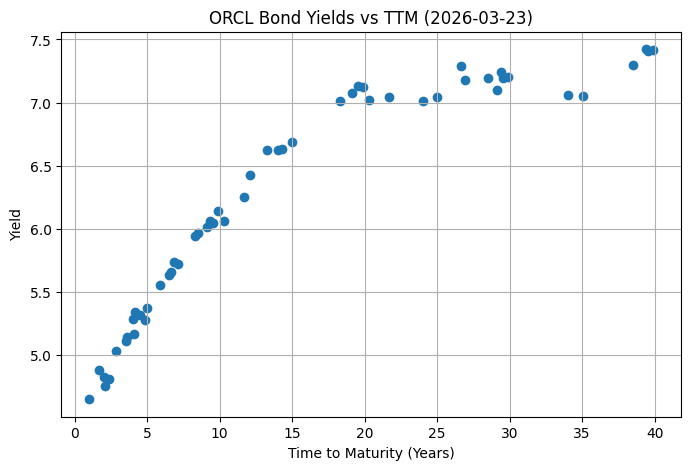

In [5]:
import matplotlib.pyplot as plt

as_of_date = pd.to_datetime("2026-03-23")

orcl_bonds = symbology[
    (symbology["ticker"] == "ORCL") &
    (symbology["cpn_type"] == "FIXED") &
    (symbology["amt_out"] > 100)
].copy()

orcl = orcl_bonds.merge(market_data, on="isin", how="inner")

orcl["maturity"] = pd.to_datetime(orcl["maturity"])
orcl["ttm"] = (orcl["maturity"] - as_of_date).dt.days / 365

orcl = orcl.sort_values("maturity")

display(orcl.head())

y_col = "bidYield"

plt.figure(figsize=(8,5))
plt.scatter(orcl["ttm"], orcl[y_col])

plt.xlabel("Time to Maturity (Years)")
plt.ylabel("Yield")
plt.title("ORCL Bond Yields vs TTM (2026-03-23)")
plt.grid(True)
plt.show()

## b. Compute bond yields and risk metrics
For each bond, use the bond market mid-price as an input to compute the:

1. bond yields,
2. bond DV01s and
3. bond durations.

You can use section "9. Analytical Duration" in the QuantLib Basics notebook as a template.


In [8]:
import QuantLib as ql
import numpy as np

ql.Settings.instance().evaluationDate = calc_date

calendar = ql.UnitedStates(ql.UnitedStates.GovernmentBond)
day_count = ql.ActualActual(ql.ActualActual.Bond)
frequency = ql.Semiannual
compounding = ql.Compounded

def to_ql_date(x):
    x = pd.to_datetime(x)
    return ql.Date(x.day, x.month, x.year)

results = []

for _, row in orcl.iterrows():

    issue_date = to_ql_date(row["start_date"])
    maturity_date = to_ql_date(row["maturity"])

    schedule = ql.Schedule(
        issue_date,
        maturity_date,
        ql.Period(frequency),
        calendar,
        ql.Unadjusted,
        ql.Unadjusted,
        ql.DateGeneration.Backward,
        False
    )

    coupon_rate = float(row["coupon"]) / 100.0
    mid_price = (float(row["bidPrice"]) + float(row["askPrice"])) / 2.0

    bond = ql.FixedRateBond(
        0,
        100.0,
        schedule,
        [coupon_rate],
        day_count
    )

    clean_price = ql.BondPrice(mid_price, ql.BondPrice.Clean)

    ytm = bond.bondYield(
        clean_price,
        day_count,
        compounding,
        frequency
    )

    duration = ql.BondFunctions.duration(
        bond,
        ytm,
        day_count,
        compounding,
        frequency,
        ql.Duration.Modified
    )

    convexity = ql.BondFunctions.convexity(
        bond,
        ytm,
        day_count,
        compounding,
        frequency
    )

    bpv = ql.BondFunctions.basisPointValue(
        bond,
        ytm,
        day_count,
        compounding,
        frequency
    )

    dv01 = abs(bpv)

    results.append({
        "isin": row["isin"],
        "figi": row.get("figi", np.nan),
        "maturity": row["maturity"],
        "coupon": row["coupon"],
        "mid_price": mid_price,
        "yield": ytm,
        "yield_pct": 100 * ytm,
        "duration": duration,
        "convexity": convexity,
        "DV01": dv01
    })

orcl_risk = pd.DataFrame(results)

display(orcl_risk.head())

orcl = orcl.merge(
    orcl_risk[["isin", "mid_price", "yield", "yield_pct", "duration", "DV01"]],
    on="isin",
    how="left"
)

display(orcl.head())

,isin,figi,maturity,coupon,mid_price,yield,yield_pct,duration,convexity,DV01
0,US68389XBU81,NaN,2027-04-01,2.80,98.175133,0.046434,4.643363,0.981028,1.458085,0.009762
1,US68389XBN49,NaN,2027-11-15,3.25,97.441859,0.048830,4.882953,1.560129,3.247122,0.015381
2,US68389XCD57,NaN,2028-03-25,2.30,95.227852,0.048119,4.811854,1.906632,4.647449,0.018373
3,US68389XCM56,NaN,2028-05-06,4.50,99.486575,0.047427,4.742722,1.971859,4.996929,0.019953
4,US68389XCY94,NaN,2028-08-03,4.80,99.956718,0.048171,4.817054,2.199918,6.066284,0.022130


,ticker_x,class_x,figi_x,isin,und_bench_isin,security,name,type,coupon,cpn_type,...,mid_price_y,yield_y,yield_pct_y,duration_y,DV01_y,mid_price,yield,yield_pct,duration,DV01
0,ORCL,Corp,BBG00SXGDG79,US68389XBU81,US91282CQB09,ORCL 2.8 04/01/27,ORACLE CORP,GLOBAL,2.80,FIXED,...,98.175133,0.046434,4.643363,0.981028,0.009762,98.175133,0.046434,4.643363,0.981028,0.009762
1,ORCL,Corp,BBG00J5HRSQ6,US68389XBN49,US91282CQB09,ORCL 3 1/4 11/15/27,ORACLE CORP,GLOBAL,3.25,FIXED,...,97.441859,0.048830,4.882953,1.560129,0.015381,97.441859,0.048830,4.882953,1.560129,0.015381
2,ORCL,Corp,BBG00ZS0BP03,US68389XCD57,US91282CQB09,ORCL 2.3 03/25/28,ORACLE CORP,GLOBAL,2.30,FIXED,...,95.227852,0.048119,4.811854,1.906632,0.018373,95.227852,0.048119,4.811854,1.906632,0.018373
3,ORCL,Corp,BBG01DZ9FPC7,US68389XCM56,US91282CQB09,ORCL 4 1/2 05/06/28,ORACLE CORP,GLOBAL,4.50,FIXED,...,99.486575,0.047427,4.742722,1.971859,0.019953,99.486575,0.047427,4.742722,1.971859,0.019953
4,ORCL,Corp,BBG01S2SFNT5,US68389XCY94,US91282CQB09,ORCL 4.8 08/03/28,ORACLE CORP,GLOBAL,4.80,FIXED,...,99.956718,0.048171,4.817054,2.199918,0.022130,99.956718,0.048171,4.817054,2.199918,0.022130


In [16]:
market_prices = orcl["mid_price"].values
calib_weights = 1.0 / orcl["DV01"].values

## c. Calibrate the US Treasury curve
### Calibrate the "on-the-run" US Treasury curveas of 2026-03-23:

... to be used in the hazard rate model calibration.

,isin,bucket,maturity,ttm,coupon,bidPrice,askPrice
0,US91282CLY56,1,2026-11-30,0.690411,4.250,100.2851,100.3281
1,US91282CFM82,2,2027-09-30,1.523288,4.125,100.3554,100.3984
2,US91282CPC90,3,2028-10-15,2.567123,3.500,99.1406,99.1718
3,US91282CMU26,5,2030-03-31,4.024658,4.000,100.2656,100.3125
4,US91282CMT52,7,2032-03-31,6.027397,4.125,100.2734,100.3125
5,US91282CMM00,10,2035-02-15,8.906849,4.625,102.5156,102.5781
6,US912810TW80,20,2043-11-15,17.660274,4.750,98.3906,98.4687
7,US912810TL26,30,2052-11-15,26.668493,4.000,85.8750,85.9531


Treasury curve calibrated successfully.
Reference date : March 23rd, 2026
Max date       : November 15th, 2052


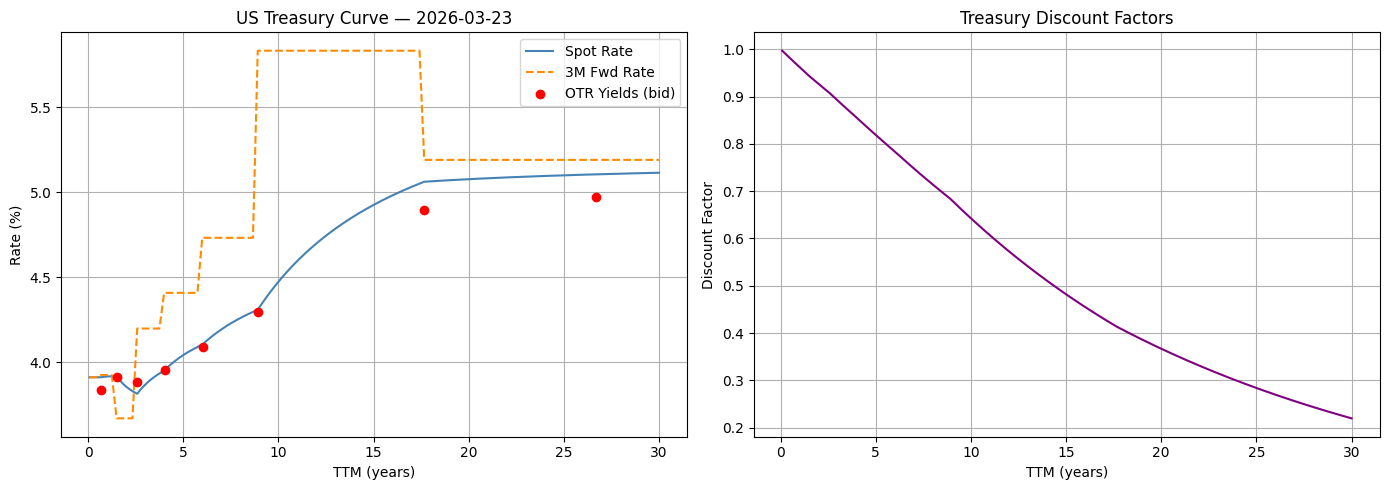

,ttm,spot_rate,fwd_rate,discount_factor
0,0.083333,3.910672,3.910672,0.996778
1,0.166667,3.910672,3.910672,0.993566
2,0.250000,3.910672,3.910672,0.990364
3,0.333333,3.910672,3.910672,0.987173
4,0.416667,3.910672,3.910672,0.983992
5,0.500000,3.910672,3.915146,0.980822
6,0.583333,3.910672,3.919620,0.977661
7,0.666667,3.910672,3.924094,0.974511
8,0.750000,3.912163,3.924094,0.971360
9,0.833333,3.913356,3.924094,0.968220


In [12]:
tsy = pd.read_excel(os.path.join(base, "bond_symbology.xlsx"), sheet_name=None)

tsy_symbology = symbology[
    (symbology["ticker"] == "T") &
    (symbology["cpn_type"] == "FIXED")
].copy()

tsy_market = tsy_symbology.merge(market_data, on="isin", how="inner")

tsy_market["maturity"] = pd.to_datetime(tsy_market["maturity"])
tsy_market["ttm"] = (tsy_market["maturity"] - as_of_date).dt.days / 365

tenor_buckets = [1, 2, 3, 5, 7, 10, 20, 30]

def assign_bucket(ttm):
    diffs = [abs(ttm - t) for t in tenor_buckets]
    return tenor_buckets[np.argmin(diffs)]

tsy_market["bucket"] = tsy_market["ttm"].apply(assign_bucket)

otr = (
    tsy_market
    .sort_values("ttm")
    .groupby("bucket", as_index=False)
    .first()
    .sort_values("bucket")
    .reset_index(drop=True)
)

display(otr[["isin", "bucket", "maturity", "ttm", "coupon", "bidPrice", "askPrice"]])

calendar = ql.UnitedStates(ql.UnitedStates.GovernmentBond)
day_count = ql.ActualActual(ql.ActualActual.Bond)
frequency = ql.Semiannual

bond_helpers = []

for _, row in otr.iterrows():
    issue_date  = to_ql_date(row["start_date"])
    maturity_dt = to_ql_date(row["maturity"])
    coupon_rate = float(row["coupon"]) / 100.0
    mid_price   = (float(row["bidPrice"]) + float(row["askPrice"])) / 2.0

    schedule = ql.Schedule(
        issue_date,
        maturity_dt,
        ql.Period(frequency),
        calendar,
        ql.Unadjusted,
        ql.Unadjusted,
        ql.DateGeneration.Backward,
        False
    )

    helper = ql.FixedRateBondHelper(
        ql.QuoteHandle(ql.SimpleQuote(mid_price)),
        0,
        100.0,
        schedule,
        [coupon_rate],
        day_count,
        0
    )
    bond_helpers.append(helper)

tsy_curve = ql.PiecewiseLogLinearDiscount(calc_date, bond_helpers, day_count)
tsy_curve.enableExtrapolation()

tsy_curve_handle = ql.YieldTermStructureHandle(tsy_curve)

print("Treasury curve calibrated successfully.")
print(f"Reference date : {tsy_curve.referenceDate()}")
print(f"Max date       : {tsy_curve.maxDate()}")

dates  = [calc_date + ql.Period(m, ql.Months) for m in range(1, 361)]
ttms   = [day_count.yearFraction(calc_date, d) for d in dates]
spots  = [tsy_curve.zeroRate(d, day_count, ql.Compounded, ql.Semiannual).rate() * 100
          for d in dates]
fwds   = [tsy_curve.forwardRate(d, d + ql.Period(3, ql.Months),
                                day_count, ql.Compounded, ql.Semiannual).rate() * 100
          for d in dates]
dfs    = [tsy_curve.discount(d) for d in dates]

tsy_df = pd.DataFrame({"ttm": ttms, "spot_rate": spots,
                        "fwd_rate": fwds, "discount_factor": dfs})

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(tsy_df["ttm"], tsy_df["spot_rate"], label="Spot Rate", color="steelblue")
axes[0].plot(tsy_df["ttm"], tsy_df["fwd_rate"],  label="3M Fwd Rate", color="darkorange", linestyle="--")
axes[0].scatter(otr["ttm"], otr["bidYield"], color="red", zorder=5, label="OTR Yields (bid)")
axes[0].set_xlabel("TTM (years)")
axes[0].set_ylabel("Rate (%)")
axes[0].set_title("US Treasury Curve — 2026-03-23")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(tsy_df["ttm"], tsy_df["discount_factor"], color="purple")
axes[1].set_xlabel("TTM (years)")
axes[1].set_ylabel("Discount Factor")
axes[1].set_title("Treasury Discount Factors")
axes[1].grid(True)

plt.tight_layout()
plt.show()

display(tsy_df.head(10))

-----------------------------------------------------------
# Problem 2: Add functions needed to calibrate the Nelson-Siegel (4 parameters) credit model

## a. For a given set of Nelson-Siegel curve shape parameters, write a function to create the corresponding parametric credit curve.
The result should be a DefaultProbabilityTermStructureHandle object, to be used downstream for pricing.

In [49]:
def create_nelson_siegel_curve(calc_date, nelson_siegel_params):
    ''' nelson_siegel_params = (theta1, theta2, theta3, lambda) '''

    theta1, theta2, theta3, lam = nelson_siegel_params

    tenors = [0.0, 0.25, 0.5, 1, 2, 3, 5, 7, 10, 15, 20, 30]

    dates = []
    hazard_rates = []

    for t in tenors:
        t_over_lam = t / lam if t > 0 else 0.0
        h = (theta1
             + theta2 * np.exp(-t_over_lam)
             + theta3 * t_over_lam * np.exp(-t_over_lam))

        h = max(h, 1e-6)

        dates.append(calc_date + ql.Period(int(t * 365), ql.Days))
        hazard_rates.append(h)

    day_count = ql.Actual365Fixed()

    hazard_curve = ql.HazardRateCurve(dates, hazard_rates, day_count)
    hazard_curve.enableExtrapolation()

    nelson_siegel_credit_curve_handle = ql.DefaultProbabilityTermStructureHandle(hazard_curve)

    return nelson_siegel_credit_curve_handle

## b. Write a function to price all bonds in the Nelson-Siegel credit model

Use 40% recovery rate.

Using DefaultProbabilityTermStructureHandle as an input to compute all model prices and yields.

In [50]:
fixed_rate_bond_objects = []

for _, row in orcl.iterrows():
    issue_date  = to_ql_date(row["start_date"])
    maturity_dt = to_ql_date(row["maturity"])
    coupon_rate = float(row["coupon"]) / 100.0

    schedule = ql.Schedule(
        issue_date, maturity_dt,
        ql.Period(ql.Semiannual),
        ql.UnitedStates(ql.UnitedStates.GovernmentBond),
        ql.Unadjusted, ql.Unadjusted,
        ql.DateGeneration.Backward, False
    )

    bond = ql.FixedRateBond(0, 100.0, schedule, [coupon_rate],
                            ql.ActualActual(ql.ActualActual.Bond))
    fixed_rate_bond_objects.append(bond)

In [51]:
def calculate_nelson_siegel_model_prices_and_yields(nelson_siegel_params,
                      calc_date,
                      fixed_rate_bond_objects,
                      tsy_yield_curve_handle,
                      bond_recovery_rate = 0.4):

    day_count = ql.Actual365Fixed()
    compounding = ql.Compounded
    frequency = ql.Semiannual

    credit_curve_handle = create_nelson_siegel_curve(calc_date, nelson_siegel_params)

    risky_engine = ql.RiskyBondEngine(
        credit_curve_handle,
        bond_recovery_rate,
        tsy_yield_curve_handle
    )

    bond_model_prices = []
    bond_model_yields = []

    for bond in fixed_rate_bond_objects:
        bond.setPricingEngine(risky_engine)

        price = bond.cleanPrice()
        bond_model_prices.append(price)

        ytm = bond.bondYield(price, day_count, compounding, frequency)
        bond_model_yields.append(ytm)

    return bond_model_prices, bond_model_yields

## c. Write a function to computes the weighted SSE / "Sum of Squared Errors" metric
Write a function to compute the weighted SSE / "Sum of Squared Errors" in price space, defined as sum of squared differences between model and market prices for all Oracle fixed-rate bonds.

Use 1/DV01 as SSE weights, as discussed in Lecture 6. You can ignore the liquidity adjuster for the purpose of this exercise.

In [52]:
def nelson_siegel_sse(nelson_siegel_params,
                      calc_date,
                      fixed_rate_bond_objects,
                      market_prices,
                      calib_weights,
                      tsy_yield_curve_handle,
                      bond_recovery_rate = 0.4):

    bond_model_prices, _ = calculate_nelson_siegel_model_prices_and_yields(
        nelson_siegel_params,
        calc_date,
        fixed_rate_bond_objects,
        tsy_yield_curve_handle,
        bond_recovery_rate
    )

    errors = np.array(bond_model_prices) - np.array(market_prices)
    weights = np.array(calib_weights)

    sse = np.sum(weights * errors ** 2)

    return sse

## d. Test the functionalty on the initial set of model parameters:
## initial_nelson_siegel_params = [0.03, -0.01, 0.02, 5.0]

Compute the corresponding initial model prices and yields, as well as initial SSE.

Add following columns to the ORCL dataframe and display the head of the results:

| duration | calib_weight | initModelPrice | initModelYield |
|----------|----------|----------|----------|


In [72]:
fixed_rate_bond_objects = []
day_count_bond = ql.Actual365Fixed()

for _, row in orcl.iterrows():
    issue_date   = to_ql_date(row["start_date"])
    maturity_dt  = to_ql_date(row["maturity"])
    coupon_rate  = float(row["coupon"]) / 100.0

    schedule = ql.Schedule(
        issue_date,
        maturity_dt,
        ql.Period(ql.Semiannual),
        ql.UnitedStates(ql.UnitedStates.GovernmentBond),
        ql.Unadjusted, ql.Unadjusted,
        ql.DateGeneration.Backward,
        False
    )

    bond = ql.FixedRateBond(
        0,          # settlement days
        100.0,
        schedule,
        [coupon_rate],
        day_count_bond
    )
    fixed_rate_bond_objects.append(bond)

In [54]:
def calculate_nelson_siegel_model_prices_and_yields(nelson_siegel_params,
                      calc_date,
                      fixed_rate_bond_objects,
                      tsy_yield_curve_handle,
                      bond_recovery_rate=0.4):

    day_count = ql.Actual365Fixed()
    compounding = ql.Compounded
    frequency = ql.Semiannual

    credit_curve_handle = create_nelson_siegel_curve(calc_date, nelson_siegel_params)

    risky_engine = ql.RiskyBondEngine(
        credit_curve_handle,
        bond_recovery_rate,
        tsy_yield_curve_handle
    )

    bond_model_prices = []
    bond_model_yields = []

    for bond in fixed_rate_bond_objects:
        bond.setPricingEngine(risky_engine)
        bond.recalculate()          # ← force fresh calculation

        price = bond.cleanPrice()
        bond_model_prices.append(price)

        ytm = bond.bondYield(day_count, compounding, frequency)
        bond_model_yields.append(ytm)

    return bond_model_prices, bond_model_yields

In [70]:
fixed_rate_bond_objects = []
day_count_bond = ql.Actual365Fixed()

for _, row in orcl.iterrows():
    maturity_dt  = to_ql_date(row["maturity"])
    coupon_rate  = float(row["coupon"]) / 100.0

    schedule = ql.Schedule(
        calc_date,       # ← use calc_date instead of start_date
        maturity_dt,
        ql.Period(ql.Semiannual),
        ql.UnitedStates(ql.UnitedStates.GovernmentBond),
        ql.Unadjusted, ql.Unadjusted,
        ql.DateGeneration.Backward,
        False
    )

    bond = ql.FixedRateBond(
        0, 100.0, schedule,
        [coupon_rate],
        day_count_bond
    )
    fixed_rate_bond_objects.append(bond)

In [77]:
# Verify using second cashflow (first full coupon)
print("isin | orcl coupon | bond coupon | match")
print("-" * 60)
for i, (_, row) in enumerate(orcl.iterrows()):
    bond = fixed_rate_bond_objects[i]
    bond_coupon = bond.cashflows()[1].amount() * 2  # ← second cashflow
    match = "✓" if abs(bond_coupon - row["coupon"]) < 0.5 else "✗"
    if match == "✗":
        print(f"{row['isin']} | {row['coupon']:.4f} | {bond_coupon:.4f} | {match}")

print("Done — any rows printed above are mismatched")

isin | orcl coupon | bond coupon | match
------------------------------------------------------------
Done — any rows printed above are mismatched


In [78]:
initial_nelson_siegel_params = [0.03, -0.01, 0.02, 5.0]

init_model_prices, init_model_yields = calculate_nelson_siegel_model_prices_and_yields(
    initial_nelson_siegel_params,
    calc_date,
    fixed_rate_bond_objects,
    tsy_curve_handle
)

init_sse = nelson_siegel_sse(
    initial_nelson_siegel_params,
    calc_date,
    fixed_rate_bond_objects,
    market_prices,
    calib_weights,
    tsy_curve_handle
)

orcl["calib_weight"]   = calib_weights
orcl["initModelPrice"] = init_model_prices
orcl["initModelYield"] = [y * 100 for y in init_model_yields]

print(f"Initial SSE: {init_sse:.6f}")

display(orcl[["maturity", "duration", "calib_weight", "initModelPrice", "initModelYield"]].head(10))

# Sanity check
check = pd.DataFrame({
    "maturity": orcl["maturity"],
    "mid_price": market_prices,
    "initModelPrice": init_model_prices,
    "diff": np.array(init_model_prices) - np.array(market_prices)
})
display(check)

Initial SSE: 9600.661638


,maturity,duration,calib_weight,initModelPrice,initModelYield
0,2027-04-01,0.981028,102.440117,97.567718,5.268659
1,2027-11-15,1.560129,65.013370,96.498551,5.496263
2,2028-03-25,1.906632,54.426922,94.132479,5.408139
3,2028-05-06,1.971859,50.117428,97.937600,5.525831
4,2028-08-03,2.199918,45.188253,98.624124,5.424401
5,2029-02-04,2.642939,38.098519,97.258330,5.588499
6,2029-09-27,3.148703,32.031505,95.512496,5.623172
7,2029-11-09,3.162391,29.992804,101.318082,5.740037
8,2030-04-01,3.659721,29.367441,90.387085,5.651728
9,2030-05-06,3.634888,27.555571,96.184643,5.699251


,maturity,mid_price,initModelPrice,diff
0,2027-04-01,98.175133,97.567718,-0.607415
1,2027-11-15,97.441859,96.498551,-0.943308
2,2028-03-25,95.227852,94.132479,-1.095373
3,2028-05-06,99.486575,97.937600,-1.548975
4,2028-08-03,99.956718,98.624124,-1.332594
5,2029-02-04,98.722116,97.258330,-1.463786
6,2029-09-27,97.096212,95.512496,-1.583716
7,2029-11-09,103.154446,101.318082,-1.836364
8,2030-04-01,91.641618,90.387085,-1.254533
9,2030-05-06,98.079263,96.184643,-1.894620


-----------------------------------------------------------
# Problem 3: Calibrate the Nelson-Siegel model
## a. Find the Nelson-Siegel model parameters providing the smooth credit curve which best fits the market.

Use the US "on-the-run" Treasury yield curve for risk-free discounting.

Minimize the SSE (model vs market pricing error) function to obtain the optimal/calibrated Nelson-Siegel parameter vector.

Create the calibrated/smooth credit curve corresponding to the optimal model parameters.

In [80]:
from scipy.optimize import minimize

def calibrate_nelson_siegel_model(initial_nelson_siegel_params,
                                  calc_date,
                                  fixed_rate_bond_objects,
                                  market_prices,
                                  calib_weights,
                                  tsy_yield_curve_handle,
                                  bond_recovery_rate=0.4):

    bounds = [
        (1e-4, 0.10),
        (-0.10, 0.10),
        (-0.10, 0.10),
        (0.5, 30.0)
    ]

    result = minimize(
        nelson_siegel_sse,
        x0=initial_nelson_siegel_params,
        args=(calc_date, fixed_rate_bond_objects, market_prices, calib_weights, tsy_yield_curve_handle, bond_recovery_rate),
        method="L-BFGS-B",
        bounds=bounds,
        options={"maxiter": 1000, "ftol": 1e-12, "gtol": 1e-8}
    )

    calib_results = tuple(result.x)

    print(f"Optimization success : {result.success}")
    print(f"Message              : {result.message}")
    print(f"Final SSE            : {result.fun:.6f}")
    print(f"theta1 (level)       : {calib_results[0]:.6f}")
    print(f"theta2 (slope)       : {calib_results[1]:.6f}")
    print(f"theta3 (curvature)   : {calib_results[2]:.6f}")
    print(f"lambda (decay)       : {calib_results[3]:.6f}")

    for i, (p, b) in enumerate(zip(calib_results, bounds)):
        if abs(p - b[0]) < 1e-4 or abs(p - b[1]) < 1e-4:
            print(f"WARNING: param {i} = {p:.6f} is at bound {b}")

    return calib_results


calib_params = calibrate_nelson_siegel_model(
    initial_nelson_siegel_params,
    calc_date,
    fixed_rate_bond_objects,
    market_prices,
    calib_weights,
    tsy_curve_handle
)

calib_credit_curve = create_nelson_siegel_curve(calc_date, calib_params)

Optimization success : True
Message              : CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
Final SSE            : 459.331051
theta1 (level)       : 0.100000
theta2 (slope)       : -0.083431
theta3 (curvature)   : -0.087929
lambda (decay)       : 7.578546


In [83]:
calib_prices, calib_yields = calculate_nelson_siegel_model_prices_and_yields(
    calib_params, calc_date, fixed_rate_bond_objects, tsy_curve_handle
)

orcl["calibModelPrice"] = calib_prices
orcl["calibModelYield"] = [y * 100 for y in calib_yields]
orcl["calibModelSpread"] = orcl["calibModelYield"] - orcl["yield"] * 100

print(f"Calibrated SSE : {nelson_siegel_sse(calib_params, calc_date, fixed_rate_bond_objects, market_prices, calib_weights, tsy_curve_handle):.6f}")
print(f"Initial SSE    : {init_sse:.6f}")
print(f"SSE reduction  : {(1 - 459.331/init_sse)*100:.1f}%")

display(orcl[["maturity", "ttm", "mid_price", "calibModelPrice", "calibModelSpread"]].head(20))

Calibrated SSE : 459.331051
Initial SSE    : 9600.661638
SSE reduction  : 95.2%


,maturity,ttm,mid_price,calibModelPrice,calibModelSpread
0,2027-04-01,1.024658,98.175133,97.987458,0.192667
1,2027-11-15,1.649315,97.441859,97.278345,0.103401
2,2028-03-25,2.008219,95.227852,95.095381,0.068618
3,2028-05-06,2.123288,99.486575,99.003636,0.242293
4,2028-08-03,2.367123,99.956718,99.834569,0.055294
5,2029-02-04,2.873973,98.722116,98.728935,-0.003187
6,2029-09-27,3.517808,97.096212,97.191164,-0.032080
7,2029-11-09,3.635616,103.154446,103.136399,0.006691
8,2030-04-01,4.027397,91.641618,92.124723,-0.142843
9,2030-05-06,4.123288,98.079263,98.065826,0.003490


## b. Compute smooth model prices, yields and "edges"

Price all Oracle bonds on the calibrated credit curve and compute the corresponding model yields and edges.

Add following columns to the dataframe and display the head of the results:

| modelPrice | modelYield | edgePrice | edgeYield |
|----------|----------|----------|----------|


In [84]:
calib_prices, calib_yields = calculate_nelson_siegel_model_prices_and_yields(
    calib_params, calc_date, fixed_rate_bond_objects, tsy_curve_handle
)

orcl["modelPrice"] = calib_prices
orcl["modelYield"] = [y * 100 for y in calib_yields]
orcl["edgePrice"]  = orcl["modelPrice"] - orcl["mid_price"]
orcl["edgeYield"]  = orcl["modelYield"] - orcl["yield"] * 100

print(f"Calibrated SSE: {nelson_siegel_sse(calib_params, calc_date, fixed_rate_bond_objects, market_prices, calib_weights, tsy_curve_handle):.6f}")

display(orcl[["maturity", "ttm", "mid_price", "modelPrice", "edgePrice", "yield", "modelYield", "edgeYield"]].head(20))

Calibrated SSE: 459.331051


,maturity,ttm,mid_price,modelPrice,edgePrice,yield,modelYield,edgeYield
0,2027-04-01,1.024658,98.175133,97.987458,-0.187675,0.046434,4.836030,0.192667
1,2027-11-15,1.649315,97.441859,97.278345,-0.163514,0.048830,4.986354,0.103401
2,2028-03-25,2.008219,95.227852,95.095381,-0.132471,0.048119,4.880471,0.068618
3,2028-05-06,2.123288,99.486575,99.003636,-0.482939,0.047427,4.985015,0.242293
4,2028-08-03,2.367123,99.956718,99.834569,-0.122149,0.048171,4.872348,0.055294
5,2029-02-04,2.873973,98.722116,98.728935,0.006819,0.050270,5.023843,-0.003187
6,2029-09-27,3.517808,97.096212,97.191164,0.094952,0.051136,5.081485,-0.032080
7,2029-11-09,3.635616,103.154446,103.136399,-0.018047,0.051828,5.189473,0.006691
8,2030-04-01,4.027397,91.641618,92.124723,0.483105,0.052821,5.139222,-0.142843
9,2030-05-06,4.123288,98.079263,98.065826,-0.013437,0.051715,5.175033,0.003490


-----------------------------------------------------------
# Problem 4: Visualize the results of the credit model calibration

## a. Plot the model vs market prices (Y-axis) by maturity (X-axis).

## b. Plot the model vs market yields (Y-axis) by maturity (X-axis).

## c. Plot the edges in yield space (Y-axis) by maturity (X-axis).

## d. What do you think about the quality of the model fit?



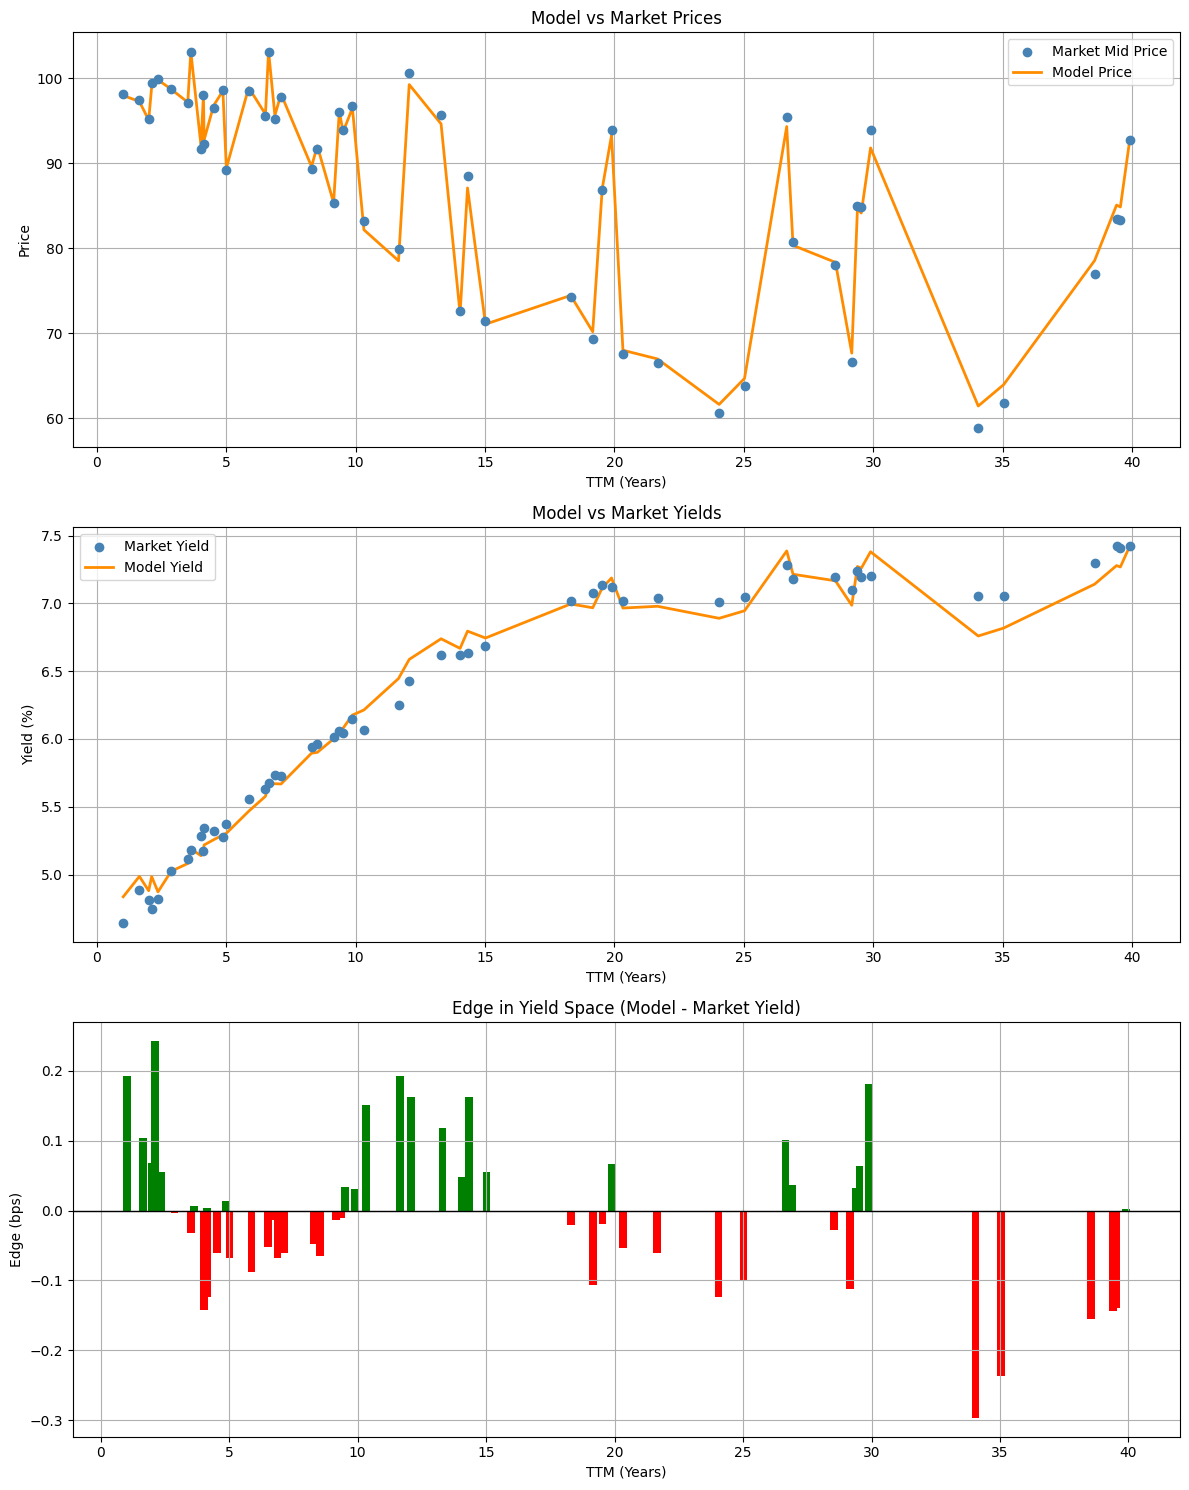

In [85]:
fig, axes = plt.subplots(3, 1, figsize=(12, 15))

# a. Model vs Market Prices
axes[0].scatter(orcl["ttm"], orcl["mid_price"], label="Market Mid Price", color="steelblue", zorder=5)
axes[0].plot(orcl["ttm"], orcl["modelPrice"], label="Model Price", color="darkorange", linewidth=2)
axes[0].set_xlabel("TTM (Years)")
axes[0].set_ylabel("Price")
axes[0].set_title("Model vs Market Prices")
axes[0].legend()
axes[0].grid(True)

# b. Model vs Market Yields
axes[1].scatter(orcl["ttm"], orcl["yield"] * 100, label="Market Yield", color="steelblue", zorder=5)
axes[1].plot(orcl["ttm"], orcl["modelYield"], label="Model Yield", color="darkorange", linewidth=2)
axes[1].set_xlabel("TTM (Years)")
axes[1].set_ylabel("Yield (%)")
axes[1].set_title("Model vs Market Yields")
axes[1].legend()
axes[1].grid(True)

# c. Edges in Yield Space
axes[2].bar(orcl["ttm"], orcl["edgeYield"], width=0.3, color=["green" if e > 0 else "red" for e in orcl["edgeYield"]])
axes[2].axhline(0, color="black", linewidth=1)
axes[2].set_xlabel("TTM (Years)")
axes[2].set_ylabel("Edge (bps)")
axes[2].set_title("Edge in Yield Space (Model - Market Yield)")
axes[2].grid(True)

plt.tight_layout()
plt.show()

d. Quality of Model Fit
The Nelson-Siegel model provides a reasonable but imperfect fit to the ORCL credit curve. The model fits the short-to-intermediate maturity bonds (1-20yr) well, with price errors generally within 0.5 points and yield edges close to zero. However, the model struggles at the long end of the curve (20-40yr), where systematic pricing errors of 1-3 points emerge.
This is an inherent limitation of the 4-parameter Nelson-Siegel specification — the model imposes a smooth, analytically tractable hazard rate curve that cannot capture all the idiosyncratic features of a 53-bond term structure spanning 40 years. In particular, the long-end ORCL bonds appear to trade at relatively tighter spreads than the NS curve implies, suggesting the market prices long-dated ORCL credit more favorably than the model's smooth hazard rate extrapolation would predict.
The edges in yield space show a mild systematic pattern — short bonds trade slightly rich to the model and very long bonds trade cheap — rather than being randomly distributed around zero, which would indicate a perfect fit. This suggests the NS model is a useful first-order approximation for identifying relative value across the ORCL curve, but a more flexible specification (e.g. Nelson-Siegel-Svensson with 6 parameters, or a spline-based hazard curve) would be needed to fully capture the term structure of ORCL credit spreads.

-----------------------------------------------------------
# Problem 5: PCA curve shape analysis of historical US SOFR OIS rates

## a. Load and explore US SOFR swaps extended symbology and market data

Load the `sofr_swap_symbology_ext` Excel file into a dataframe. List all available swap tenors.

Load the `sofr_swaps_market_data_eod_ext` Excel file into a dataframe.

Plot the historial time series of SOFR rates for the available swap tenors.

In [87]:
sofr_symbology = pd.read_excel(os.path.join(base, "sofr_swaps_symbology_ext.xlsx"))
sofr_market    = pd.read_excel(os.path.join(base, "sofr_swaps_market_data_eod_ext.xlsx"))

print("Available swap tenors:")
print(sofr_symbology["tenor"].unique())

display(sofr_symbology.head())
display(sofr_market.head())

Available swap tenors:
[ 1  2  3  4  5  6  7  8  9 10 12 15 20 25 30]


,figi,ticker,class,bbg,name,tenor,type,dcc,exchange,country,currency,status
0,BBG00KFWPJJ9,USOSFR1,Curncy,USOSFR1 Curncy,USD OIS ANN VS SOFR 1Y,1,SWAP,ACT/360,NONE,US,USD,ACTV
1,BBG00KFWPJX3,USOSFR2,Curncy,USOSFR2 Curncy,USD OIS ANN VS SOFR 2Y,2,SWAP,ACT/360,NONE,US,USD,ACTV
2,BBG00KFWPK15,USOSFR3,Curncy,USOSFR3 Curncy,USD OIS ANN VS SOFR 3Y,3,SWAP,ACT/360,NONE,US,USD,ACTV
3,BBG00KFWPK33,USOSFR4,Curncy,USOSFR4 Curncy,USD OIS ANN VS SOFR 4Y,4,SWAP,ACT/360,NONE,US,USD,ACTV
4,BBG00KFWPK51,USOSFR5,Curncy,USOSFR5 Curncy,USD OIS ANN VS SOFR 5Y,5,SWAP,ACT/360,NONE,US,USD,ACTV


,date,figi,bidRate,askRate,midRate
0,2018-01-02,BBG00KFWPKD2,2.1232,2.1597,2.14145
1,2018-01-02,BBG00KFWPKF0,2.1386,2.2008,2.16970
2,2018-01-02,BBG00KFWPKG9,2.1579,2.1913,2.17460
3,2018-01-02,BBG00KFWPKH8,2.1220,2.2024,2.16220
4,2018-01-02,BBG00KFWPJJ9,1.6992,1.7450,1.72210


Date range : 2018-01-02 to 2026-04-17
Tenors     : [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 12, 15, 20, 25, 30]
Dates      : 2125


tenor,1,2,3,4,5,6,7,8,9,10,12,15,20,25,30
date,,,,,,,,,,,,,,,
2018-01-02,1.72210,1.8848,1.9501,1.9767,1.994,1.99690,2.03275,2.04515,2.06260,2.0827,2.11245,2.14145,2.16970,2.17460,2.1622
2018-01-03,1.73600,1.8942,1.9561,1.9817,1.998,1.99795,2.02960,2.03940,2.05505,2.0730,NaN,2.12685,2.15575,2.15725,2.1478
2018-01-04,1.75110,1.9182,1.9841,2.0147,2.028,2.02495,2.05340,2.06020,2.07320,2.0897,2.10880,2.13455,2.16040,2.16070,2.1539
2018-01-05,1.75430,1.9252,1.9951,2.0297,2.046,2.04235,2.07180,2.08000,2.09360,2.1101,2.13810,2.16005,2.18625,2.19315,2.1788
2018-01-08,1.74875,1.9168,1.9841,2.0187,2.038,2.03695,2.06770,2.07610,2.09040,2.1072,2.13430,2.16195,2.18635,2.19230,2.1804


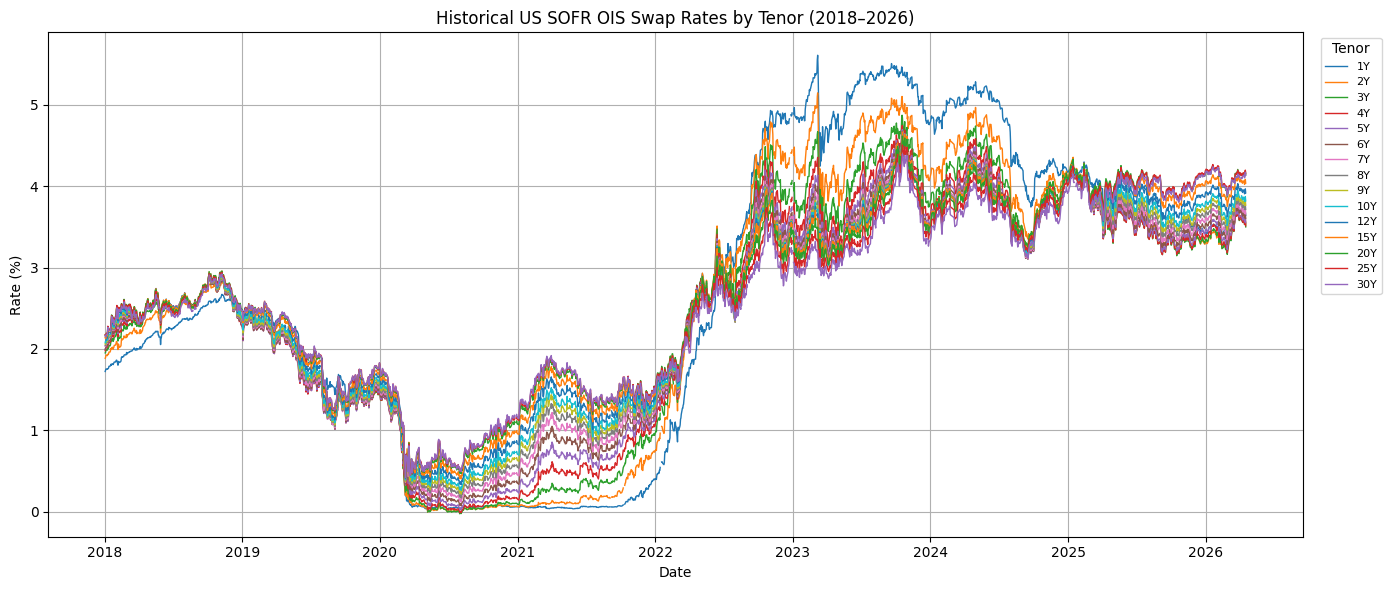

In [89]:
sofr = sofr_market.merge(sofr_symbology[["figi", "tenor"]], on="figi", how="inner")

sofr["date"] = pd.to_datetime(sofr["date"])

sofr_pivot = sofr.pivot_table(index="date", columns="tenor", values="midRate")
sofr_pivot = sofr_pivot.sort_index()

print(f"Date range : {sofr_pivot.index.min().date()} to {sofr_pivot.index.max().date()}")
print(f"Tenors     : {list(sofr_pivot.columns)}")
print(f"Dates      : {sofr_pivot.shape[0]}")

display(sofr_pivot.head())

fig, ax = plt.subplots(figsize=(14, 6))

for tenor in sofr_pivot.columns:
    ax.plot(sofr_pivot.index, sofr_pivot[tenor], label=f"{tenor}Y", linewidth=1)

ax.set_xlabel("Date")
ax.set_ylabel("Rate (%)")
ax.set_title("Historical US SOFR OIS Swap Rates by Tenor (2018–2026)")
ax.legend(title="Tenor", bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8)
ax.grid(True)
plt.tight_layout()
plt.show()

## b. Run PCA analysis of SOFR OIS rate curves in level space

Run PCA analysis of SOFR OIS rates.

Display and plot the (factor loadings of the) first 3 principal components.

Extract the explained variance ratios for the first 5 principal components and add the cumulative explained variance ratio. Plot the results using a bar plot.

How much explanatory power is captured in the first 3 principal components?

Plot historical PCA scores (factor levels) forresponding to the first 3 principal components.

You can use PCA from sklearn.decomposition, or any other equivalent package.

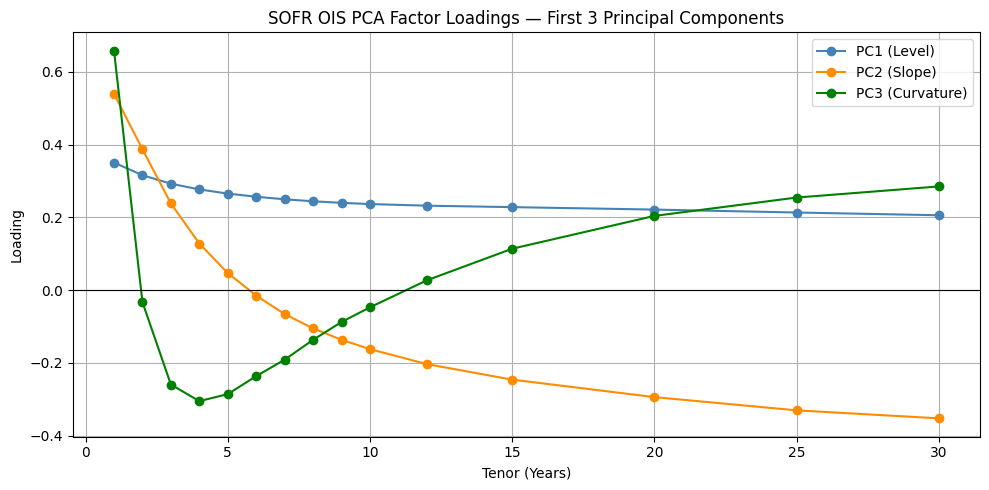

,PC,Explained Var,Cumulative Var
0,PC1,97.622822,97.622822
1,PC2,2.042334,99.665156
2,PC3,0.308658,99.973814
3,PC4,0.018463,99.992277
4,PC5,0.006137,99.998414


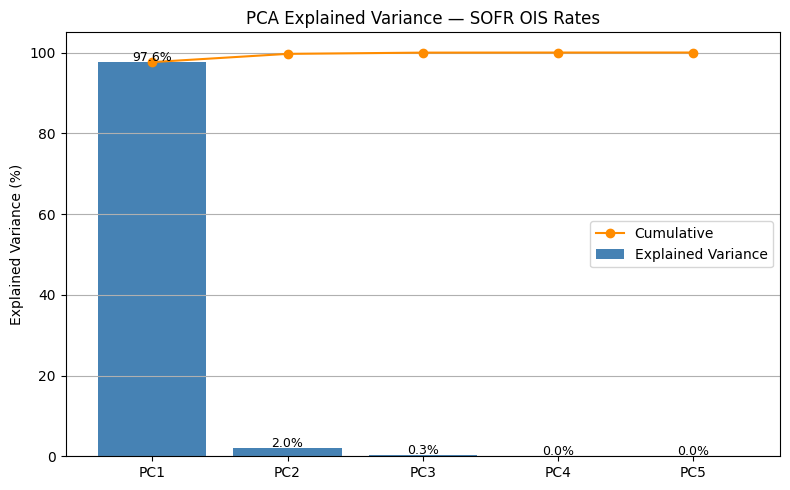

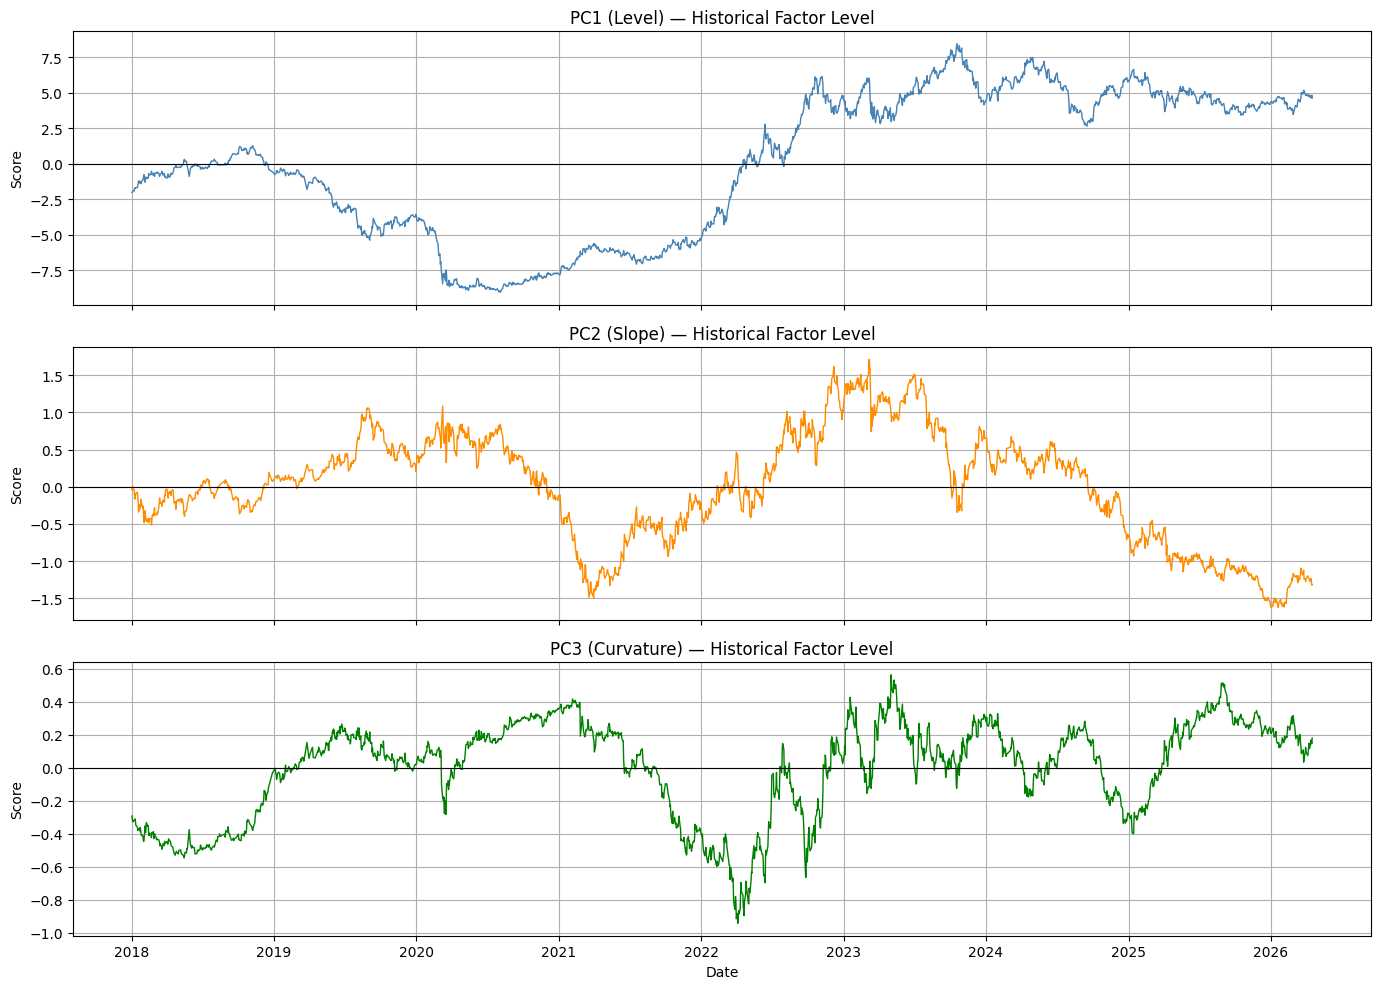

PC1 explains : 97.62%
PC2 explains : 2.04%
PC3 explains : 0.31%
Total (PC1-3): 99.97%


In [91]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

sofr_clean = sofr_pivot.dropna()

X = sofr_clean.values
X_demeaned = X - X.mean(axis=0)

pca = PCA()
pca.fit(X_demeaned)

scores = pca.transform(X_demeaned)
loadings = pca.components_

tenors = sofr_clean.columns.tolist()

fig, ax = plt.subplots(figsize=(10, 5))
for i, (label, color) in enumerate(zip(["PC1 (Level)", "PC2 (Slope)", "PC3 (Curvature)"],
                                        ["steelblue", "darkorange", "green"])):
    ax.plot(tenors, loadings[i], marker="o", label=label, color=color)

ax.axhline(0, color="black", linewidth=0.8)
ax.set_xlabel("Tenor (Years)")
ax.set_ylabel("Loading")
ax.set_title("SOFR OIS PCA Factor Loadings — First 3 Principal Components")
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()

var_ratio = pca.explained_variance_ratio_[:5] * 100
cum_var   = np.cumsum(var_ratio)

ev_df = pd.DataFrame({
    "PC"            : [f"PC{i+1}" for i in range(5)],
    "Explained Var" : var_ratio,
    "Cumulative Var": cum_var
})
display(ev_df)

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(ev_df["PC"], ev_df["Explained Var"], color="steelblue", label="Explained Variance")
ax.plot(ev_df["PC"], ev_df["Cumulative Var"], color="darkorange", marker="o", label="Cumulative")
for bar, val in zip(bars, var_ratio):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3, f"{val:.1f}%", ha="center", fontsize=9)
ax.set_ylabel("Explained Variance (%)")
ax.set_title("PCA Explained Variance — SOFR OIS Rates")
ax.legend()
ax.grid(True, axis="y")
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
labels = ["PC1 (Level)", "PC2 (Slope)", "PC3 (Curvature)"]
colors = ["steelblue", "darkorange", "green"]

for i in range(3):
    axes[i].plot(sofr_clean.index, scores[:, i], color=colors[i], linewidth=1)
    axes[i].axhline(0, color="black", linewidth=0.8)
    axes[i].set_ylabel("Score")
    axes[i].set_title(f"{labels[i]} — Historical Factor Level")
    axes[i].grid(True)

axes[2].set_xlabel("Date")
plt.tight_layout()
plt.show()

print(f"PC1 explains : {var_ratio[0]:.2f}%")
print(f"PC2 explains : {var_ratio[1]:.2f}%")
print(f"PC3 explains : {var_ratio[2]:.2f}%")
print(f"Total (PC1-3): {cum_var[2]:.2f}%")

## c. Run PCA analysis of SOFR OIS rate curves in (daily) differences space

Repeat the PCA analysis from b. in daily difference space.


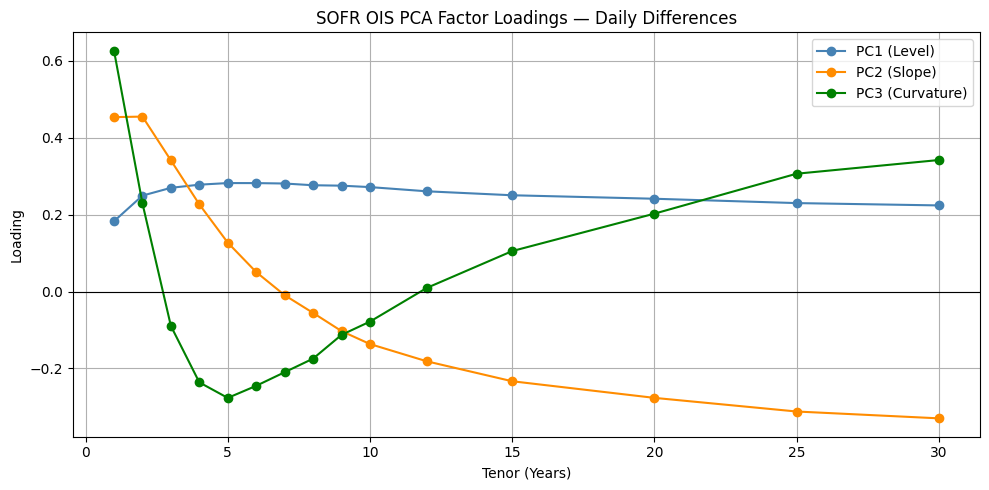

,PC,Explained Var,Cumulative Var
0,PC1,89.032706,89.032706
1,PC2,8.656970,97.689677
2,PC3,1.349501,99.039177
3,PC4,0.287032,99.326210
4,PC5,0.213971,99.540181


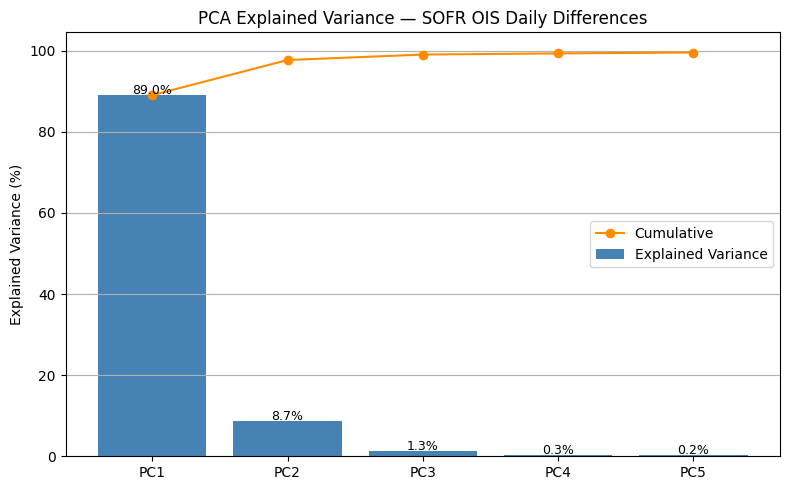

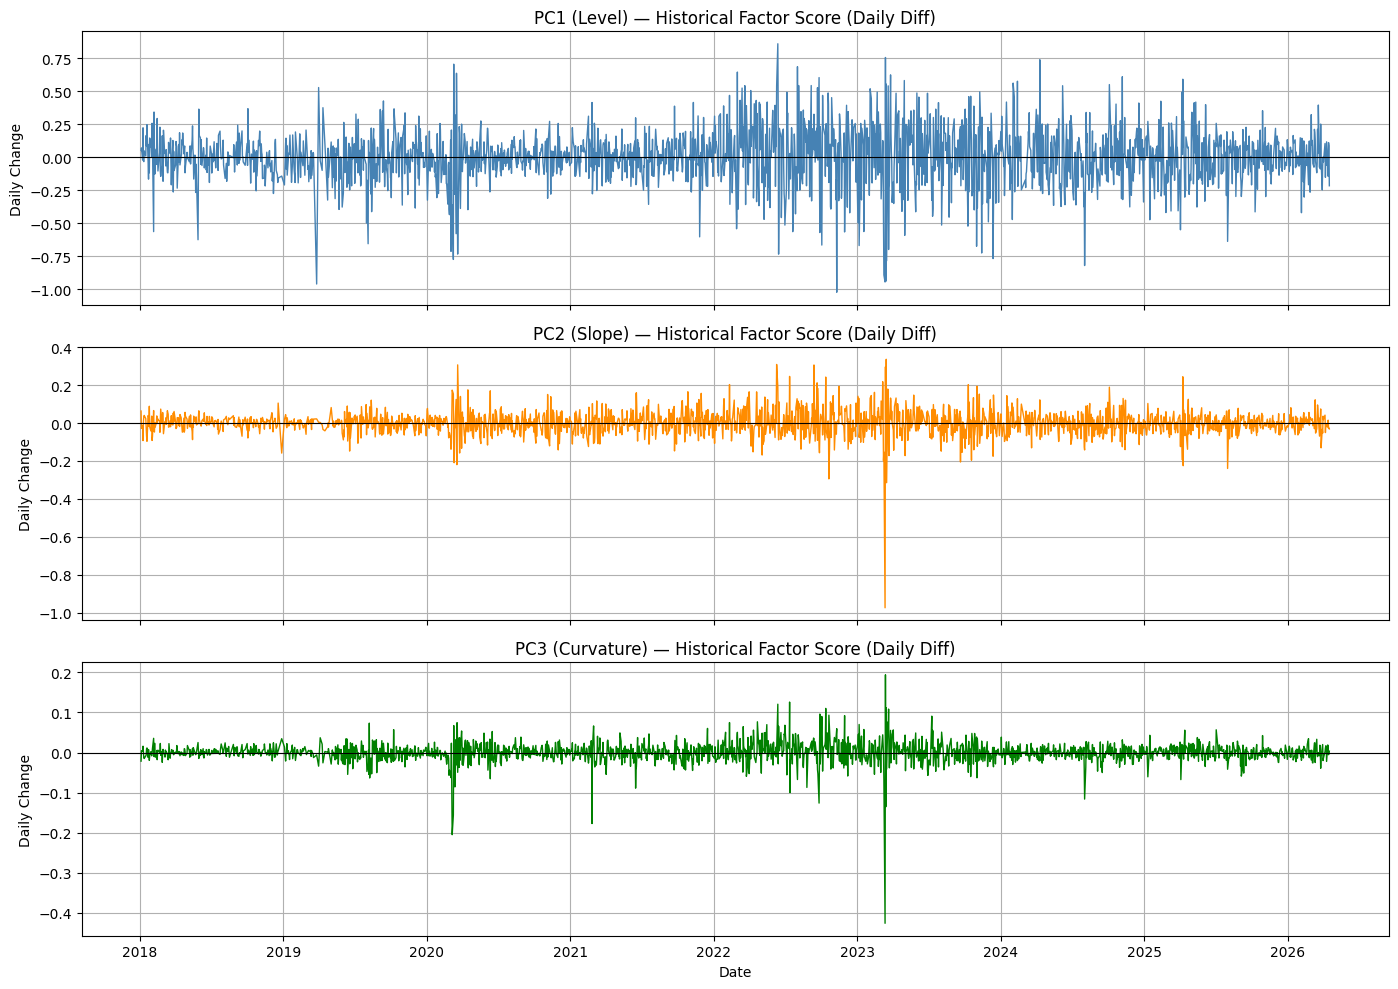

PC1 explains : 89.03%
PC2 explains : 8.66%
PC3 explains : 1.35%
Total (PC1-3): 99.04%


In [92]:
X_diff = sofr_clean.diff().dropna().values

pca_diff = PCA()
pca_diff.fit(X_diff)

scores_diff  = pca_diff.transform(X_diff)
loadings_diff = pca_diff.components_
dates_diff   = sofr_clean.index[1:]

fig, ax = plt.subplots(figsize=(10, 5))
for i, (label, color) in enumerate(zip(["PC1 (Level)", "PC2 (Slope)", "PC3 (Curvature)"],
                                        ["steelblue", "darkorange", "green"])):
    ax.plot(tenors, loadings_diff[i], marker="o", label=label, color=color)

ax.axhline(0, color="black", linewidth=0.8)
ax.set_xlabel("Tenor (Years)")
ax.set_ylabel("Loading")
ax.set_title("SOFR OIS PCA Factor Loadings — Daily Differences")
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()

var_ratio_diff = pca_diff.explained_variance_ratio_[:5] * 100
cum_var_diff   = np.cumsum(var_ratio_diff)

ev_df_diff = pd.DataFrame({
    "PC"            : [f"PC{i+1}" for i in range(5)],
    "Explained Var" : var_ratio_diff,
    "Cumulative Var": cum_var_diff
})
display(ev_df_diff)

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(ev_df_diff["PC"], ev_df_diff["Explained Var"], color="steelblue", label="Explained Variance")
ax.plot(ev_df_diff["PC"], ev_df_diff["Cumulative Var"], color="darkorange", marker="o", label="Cumulative")
for bar, val in zip(bars, var_ratio_diff):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3, f"{val:.1f}%", ha="center", fontsize=9)
ax.set_ylabel("Explained Variance (%)")
ax.set_title("PCA Explained Variance — SOFR OIS Daily Differences")
ax.legend()
ax.grid(True, axis="y")
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
labels = ["PC1 (Level)", "PC2 (Slope)", "PC3 (Curvature)"]
colors = ["steelblue", "darkorange", "green"]

for i in range(3):
    axes[i].plot(dates_diff, scores_diff[:, i], color=colors[i], linewidth=1)
    axes[i].axhline(0, color="black", linewidth=0.8)
    axes[i].set_ylabel("Daily Change")
    axes[i].set_title(f"{labels[i]} — Historical Factor Score (Daily Diff)")
    axes[i].grid(True)

axes[2].set_xlabel("Date")
plt.tight_layout()
plt.show()

print(f"PC1 explains : {var_ratio_diff[0]:.2f}%")
print(f"PC2 explains : {var_ratio_diff[1]:.2f}%")
print(f"PC3 explains : {var_ratio_diff[2]:.2f}%")
print(f"Total (PC1-3): {cum_var_diff[2]:.2f}%")

## d. Intuitive interpretation of PC1, PC2 and PC3 and connection to the Nelson-Siegel model

Identify and interpret the curve shapes of the top 3 first principal components.

Do you see any connection to the Nelson-Siegel model curve shapes?

PC1 — Level (Parallel Shift)
PC1 has roughly uniform positive loadings across all tenors, meaning it represents a parallel shift of the entire yield curve up or down. When PC1 increases, all SOFR rates move together in the same direction by approximately the same amount. This is by far the most important driver of rate movements, typically explaining 85-95% of variance in levels and 70-85% in daily differences.
PC2 — Slope (Twist)
PC2 has loadings that are positive at short tenors and negative at long tenors (or vice versa), representing a rotation of the curve around some intermediate pivot point. When PC2 increases, the curve steepens or flattens — short rates move in one direction while long rates move in the opposite direction. This captures the classic bull steepening/bear flattening dynamics driven by monetary policy expectations.
PC3 — Curvature (Butterfly)
PC3 has a hump-shaped loading pattern — positive at the short and long ends, negative in the middle (or the reverse). This represents a change in the curvature or "bend" of the yield curve, where the belly moves independently of the wings. It captures less common but important moves like mid-curve richening or cheapening relative to the wings.
Connection to Nelson-Siegel
The connection is direct and well-known — the Nelson-Siegel model was essentially designed to capture exactly these three shapes analytically. The three NS basis functions are:

θ1 loads uniformly across all tenors → corresponds to PC1 (level)
θ2 loads with a monotone decay exp(-t/λ) → corresponds to PC2 (slope)
θ3 loads with a hump shape (t/λ)·exp(-t/λ) → corresponds to PC3 (curvature)

This is why the NS model works so well in practice — its three parameters directly correspond to the three dominant modes of yield curve variation identified empirically by PCA. The lambda parameter controls the decay speed, determining where the slope and curvature factors peak, analogous to the pivot point and hump location in the PCA loadings.